In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SHAPEFILE = "../dashboard_alerts-shapefile/dashboard_alerts_shapefile.shp"

gdf = gpd.read_file(SHAPEFILE)

print("\n=== BASIC INFO ===")
#print(gdf.head())
print("\nColumns:")
print(gdf.columns.tolist())
print("\nShape:")
print(gdf.shape)
print("\nCRS:")
print(gdf.crs)

#gdf.plot(figsize=(10, 10),edgecolor='black')


=== BASIC INFO ===

Columns:
['codealerta', 'fonte', 'biome', 'department', 'municipali', 'watershedl', 'regions', 'raisglimit', 'indigenous', 'forestres', 'natinatupr', 'areaha', 'anodetec', 'datadetec', 'dtimgant', 'dtimgdep', 'dtpubli', 'vpressao', 'geometry']

Shape:
(15979, 19)

CRS:
EPSG:4326


<DatetimeArray>
['2025-03-31 00:00:00', '2020-03-31 00:00:00', '2020-06-30 00:00:00',
 '2020-09-30 00:00:00', '2020-12-31 00:00:00', '2021-03-31 00:00:00',
 '2021-06-30 00:00:00', '2021-09-30 00:00:00', '2021-12-31 00:00:00',
 '2022-03-31 00:00:00',
 ...
 '2026-01-31 00:00:00', '2026-02-11 00:00:00', '2026-02-17 00:00:00',
 '2026-01-12 00:00:00', '2026-02-08 00:00:00', '2026-01-15 00:00:00',
 '2026-02-05 00:00:00', '2026-02-26 00:00:00', '2026-02-04 00:00:00',
 '2026-02-23 00:00:00']
Length: 390, dtype: datetime64[us]


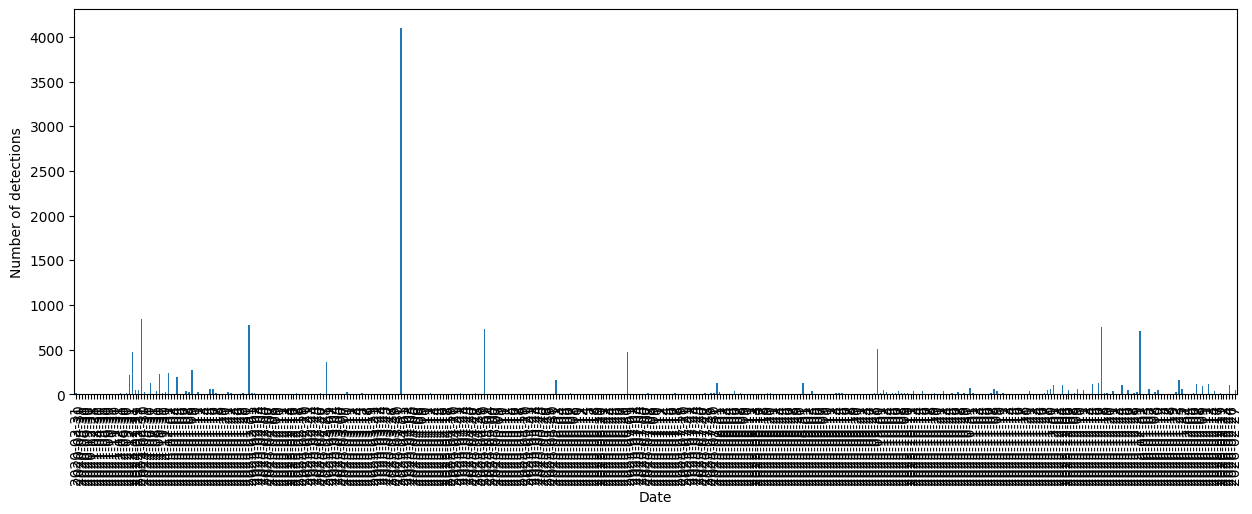

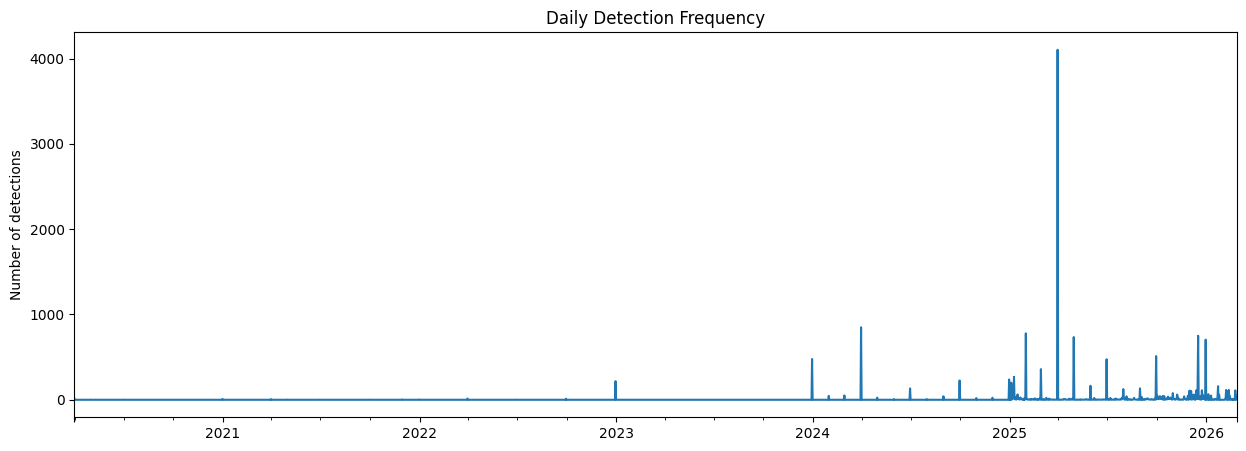

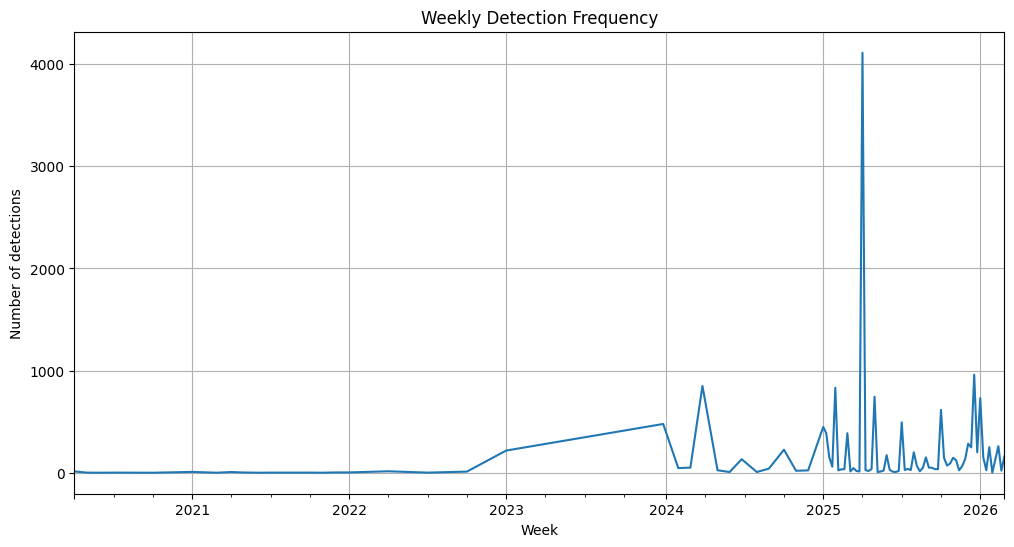

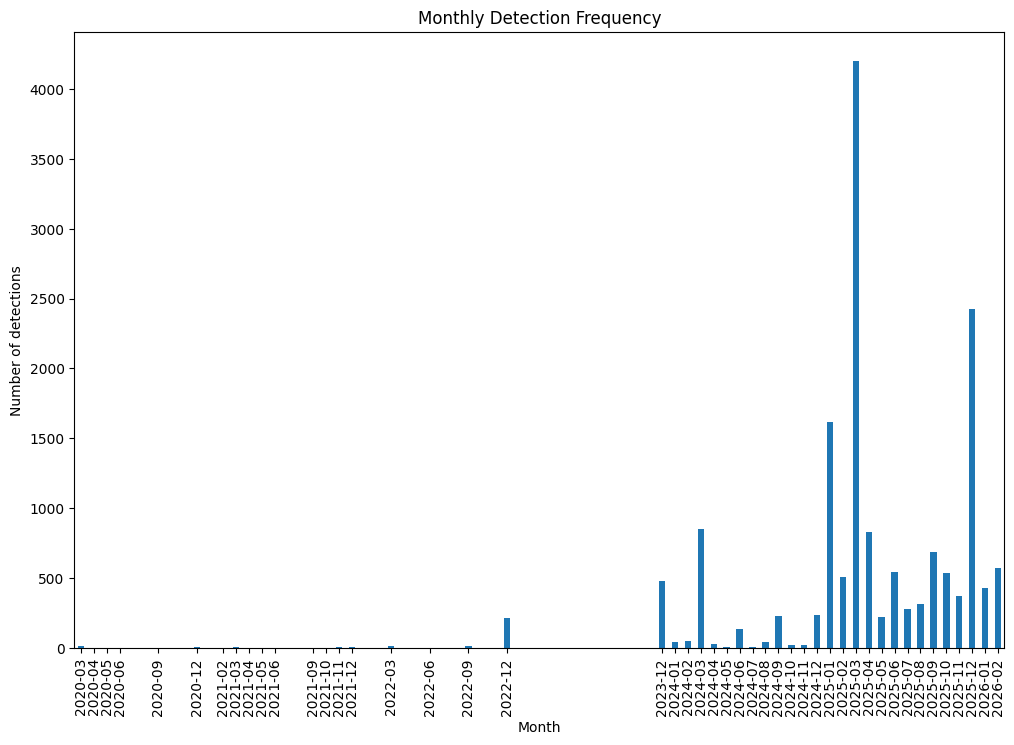

In [6]:
gdf["datadetec"] = pd.to_datetime(gdf["datadetec"])

date_counts = gdf["datadetec"].value_counts().sort_index()

print(gdf["datadetec"].unique())

all_dates = pd.date_range(
    start=gdf["datadetec"].min(),
    end=gdf["datadetec"].max(),
    freq="D"
)

daily_counts = date_counts.reindex(all_dates, fill_value=0)

date_counts.index = date_counts.index.strftime("%Y-%m-%d")

plt.figure(figsize=(15, 5))
date_counts.plot(kind="bar")
plt.ylabel("Number of detections")
plt.xlabel("Date")
plt.show()

plt.figure(figsize=(15, 5))
daily_counts.plot()
plt.ylabel("Number of detections")
plt.title("Daily Detection Frequency")
plt.show()

#weekly_counts = daily_counts.resample("W").sum()
weekly_counts = (
    gdf.groupby(
        gdf["datadetec"].dt.to_period("W")
    )
    .size()
)
#print(weekly_counts)

plt.figure(figsize=(12, 6))
weekly_counts.plot()
plt.xlabel("Week")
plt.ylabel("Number of detections")
plt.title("Weekly Detection Frequency")
plt.grid(True)
plt.show()

monthly_counts = (
    gdf.groupby(
        gdf["datadetec"].dt.to_period("M")
    )
    .size()
)

plt.figure(figsize=(12, 8))
monthly_counts.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Number of detections")
plt.title("Monthly Detection Frequency")
plt.show()

<StringArray>
['GAIA', 'GLAD-S', 'LUCA', 'RADD', 'IDEAM', 'JJ-FAST', 'GLAD-L', 'DIST']
Length: 8, dtype: str
      codealerta    fonte  biome          department municipali watershedl  \
1000    40053736  [IDEAM]  Andes  Norte de Santander  El Carmen  El Carmen   

     regions raisglimit indigenous                               forestres  \
1000   Andes        NaN         ()  ("Serranía de los Motilones - Tipo A")   

     natinatupr  areaha  anodetec  datadetec    dtimgant    dtimgdep  \
1000         ()     1.1    2024.0 2024-03-31  2024-01-16  2024-02-18   

         dtpubli vpressao                                           geometry  
1000  2025-11-21  farming  POLYGON ((-73.3535 8.8296, -73.35347 8.82955, ...  
fonte
DIST        246
GAIA       2575
GLAD-L     3887
GLAD-S     7284
IDEAM      9874
JJ-FAST     288
LUCA       4332
RADD       3440
Name: count, dtype: int64


Text(0.5, 0, 'Source')

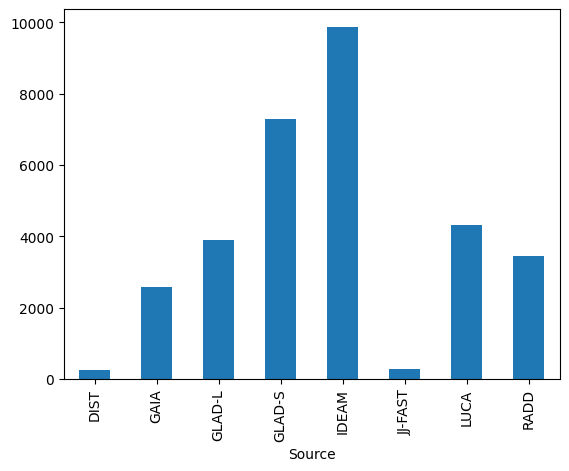

In [ ]:
gdf["fonte"] = (
    gdf["fonte"]
	.str.strip("{}")
	.str.split(",")
)
print(gdf["fonte"].explode().unique())

counts = (
    gdf["fonte"]
    .explode()
    .value_counts()
    .sort_index()
)

print(counts)

counts.plot(kind="bar")
plt.xlabel("Source")

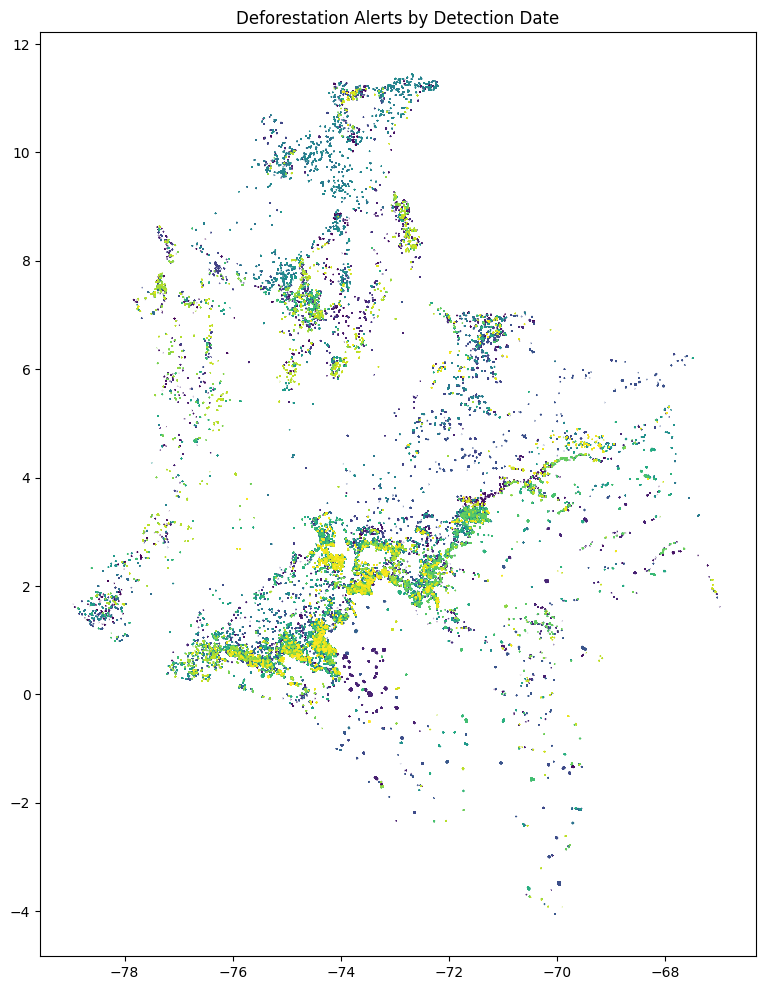

In [11]:
gdf["date_num"] = gdf["datadetec"].map(pd.Timestamp.toordinal)

fig, ax = plt.subplots(figsize=(12, 12))

gdf.boundary.plot(
    ax=ax,
    label="date_num",
    cmap="viridis",
    linewidth=1,
    #legend=True
)

plt.title("Deforestation Alerts by Detection Date")
plt.show()